## 01. Entedendo o problema

In [1]:
# Importando bibliotecas
import pandas as  pd 
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm

In [2]:

dados = pd.read_csv('clientes_restaurantes.csv')
dados.head()

,data,Chimi & Churri,Assa Frão
0,1/1/2016,65.0,139.0
1,1/2/2016,24.0,85.0
2,1/3/2016,24.0,81.0
3,1/4/2016,23.0,32.0
4,1/5/2016,2.0,43.0


In [3]:
dados.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            478 non-null    object 
 1   Chimi & Churri  476 non-null    float64
 2   Assa Frão       477 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.3+ KB


In [4]:

# transformação de colunas de data para datetime
dados['data'] = pd.to_datetime(dados['data'])
dados.set_index('data', inplace=True)

In [5]:
dados

,Chimi & Churri,Assa Frão
data,,
2016-01-01,65.0,139.0
2016-01-02,24.0,85.0
2016-01-03,24.0,81.0
2016-01-04,23.0,32.0
2016-01-05,2.0,43.0
...,...,...
2017-04-18,30.0,18.0
2017-04-19,20.0,18.0
2017-04-20,22.0,46.0


In [ ]:
# Verificando dados nulos por linhas
dados['Chimi & Churri'][dados['Chimi & Churri'].isnull()]

data
2016-04-05   NaN
2016-09-17   NaN
Name: Chimi & Churri, dtype: float64

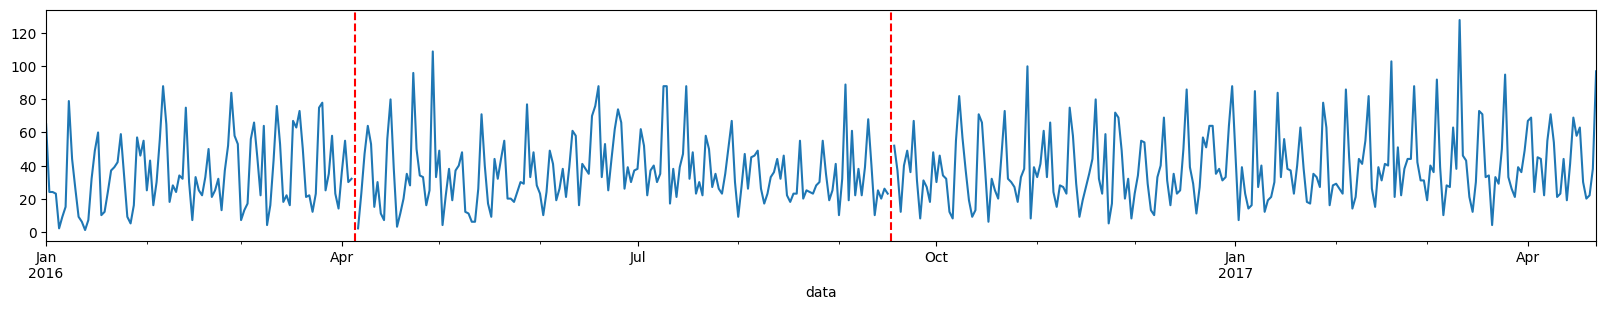

In [13]:
# Visualizando dados nulos atraves de grafico com axvline

dados['Chimi & Churri'].plot(figsize=(20,3))
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isnull()].index[0], color='red', linestyle='--')
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isnull()].index[1], color='red', linestyle='--');

In [15]:
dados['Assa Frão'][dados['Assa Frão'].isnull()]

data
2016-11-24   NaN
Name: Assa Frão, dtype: float64

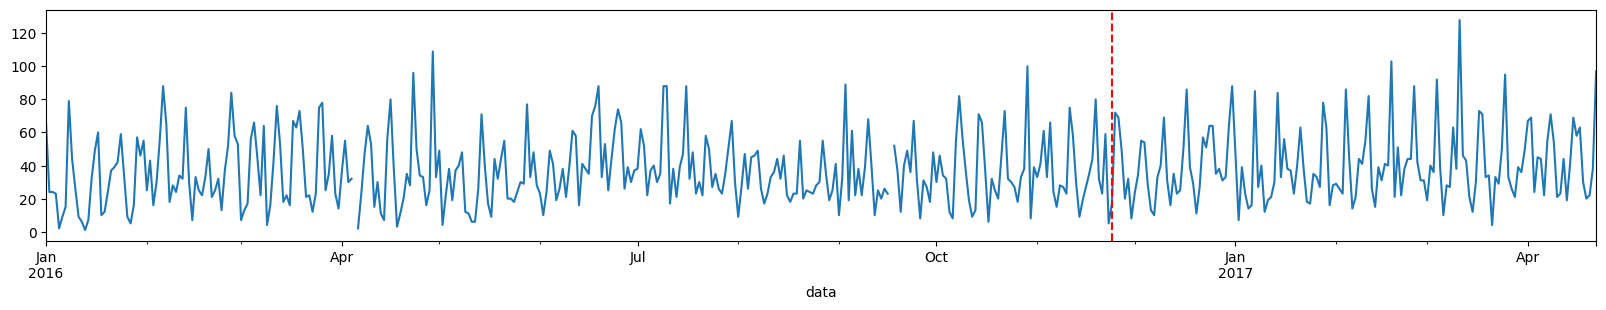

In [17]:
dados['Chimi & Churri'].plot(figsize=(20,3))
plt.axvline(x = dados['Assa Frão'][dados['Assa Frão'].isnull()].index[0], color='red', linestyle='--')


In [22]:
## Preenchimento de dados nulos com interpolação linear
dados = dados.interpolate().round()

In [23]:
# Verificando se os dados nulos foram preenchidos com interpolação
dados.loc['2016-04-04':'2016-04-06']

,Chimi & Churri,Assa Frão
data,,
2016-04-04,32.0,12.0
2016-04-05,17.0,34.0
2016-04-06,2.0,40.0


In [25]:
# resultado esperado, porem com decimal, como é uma contagem de clientes, arredondamos para inteiro
dados.loc['2016-09-16':'2016-09-18']

,Chimi & Churri,Assa Frão
data,,
2016-09-16,23.0,51.0
2016-09-17,38.0,60.0
2016-09-18,52.0,57.0


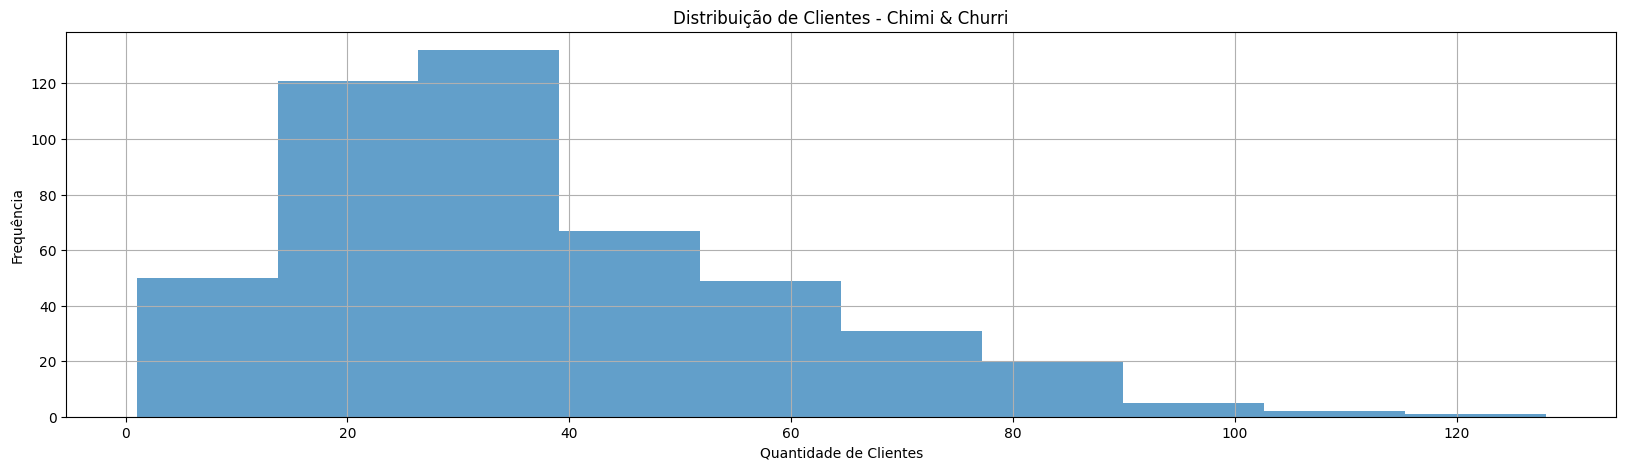

In [ ]:
# Perguntas a responder
# * Quais são os dias com maior frequencia de clientes para cada restaurante?
# * Qual é a quantidade minima que visitam ?
# * Qual é a máxima de clientes por dia para cada restaurante?

dados['Chimi & Churri'].hist(figsize=(20,5),alpha=0.7)
plt.title('Distribuição de Clientes - Chimi & Churri')
plt.xlabel('Quantidade de Clientes')
plt.ylabel('Frequência')
plt.show()

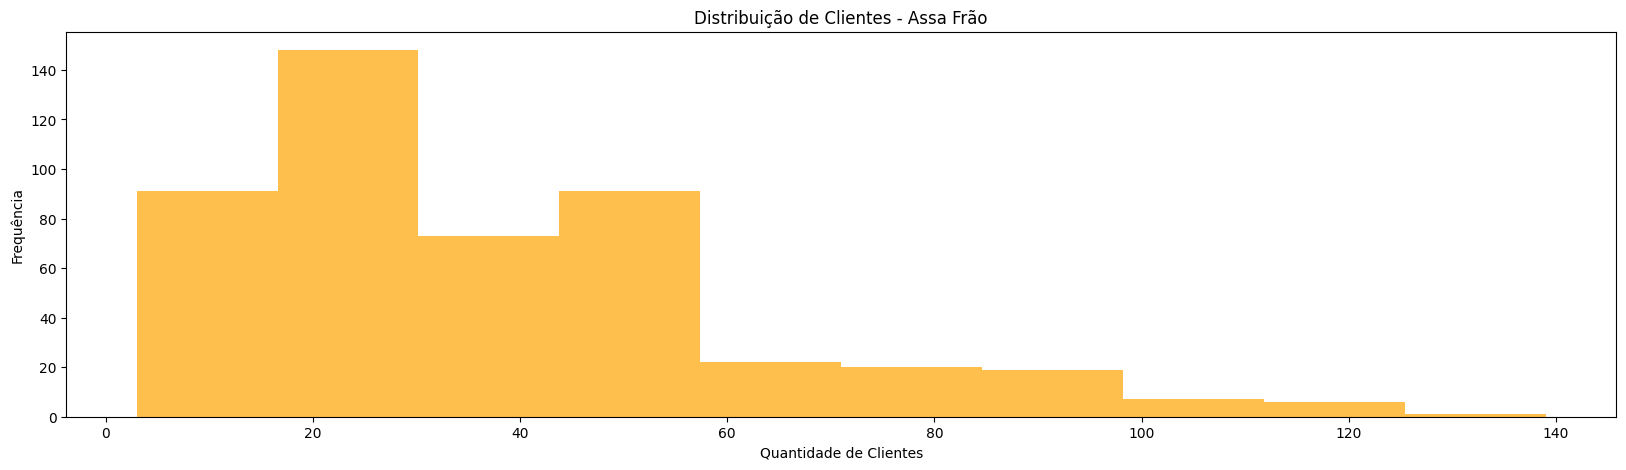

In [57]:
plt.figure(figsize=(20,5))
plt.hist(dados['Assa Frão'],alpha=0.7, color='orange')
plt.title('Distribuição de Clientes - Assa Frão')
plt.xlabel('Quantidade de Clientes')
plt.ylabel('Frequência')
plt.show()

In [58]:
dados.describe()

,Chimi & Churri,Assa Frão
count,478.000000,478.000000
mean,37.453975,37.679916
std,21.433065,24.619708
min,1.000000,3.000000
25%,22.250000,19.000000
50%,33.000000,30.500000
75%,49.000000,50.000000
max,128.000000,139.000000


In [63]:
print(f'Máximo de clientes em Chimi & Churri: {dados["Chimi & Churri"].max()}')
print(f'Mínimo de clientes em Chimi & Churri: {dados["Chimi & Churri"].min()}')
print(f'Máximo de clientes em Assa Frão: {dados["Assa Frão"].max()}')
print(f'Mínimo de clientes em Assa Frão: {dados["Assa Frão"].min()}')

Máximo de clientes em Chimi & Churri: 128
Mínimo de clientes em Chimi & Churri: 1
Máximo de clientes em Assa Frão: 139
Mínimo de clientes em Assa Frão: 3


C:\Users\init\AppData\Local\Temp\ipykernel_16260\1301076062.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dados['Chimi & Churri'], dados['Assa Frão']], labels=['Chimi & Churri', 'Assa Frão'])


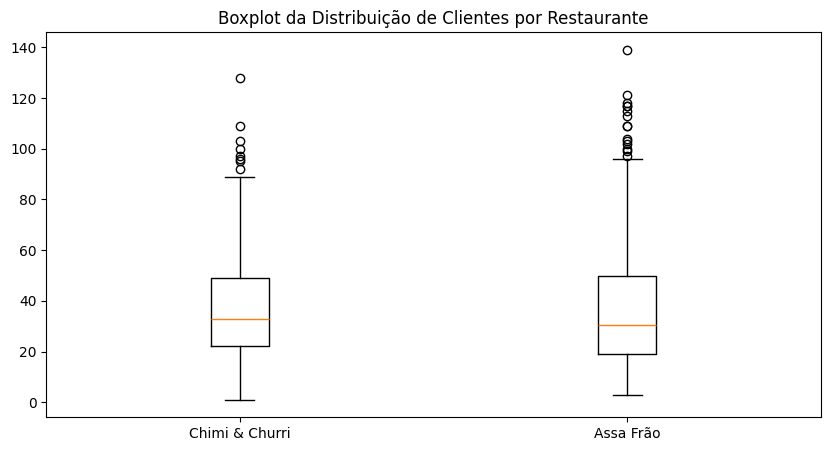

In [65]:
plt.figure(figsize=(10,5))
plt.boxplot([dados['Chimi & Churri'], dados['Assa Frão']], labels=['Chimi & Churri', 'Assa Frão'])
plt.title('Boxplot da Distribuição de Clientes por Restaurante')
plt.show()

## 02. Extraindo insights

In [77]:
# verificar o valor médio, maximo e minimo de clientes por juntando os dois restaurantes
dados['Total'] = dados['Chimi & Churri'] + dados['Assa Frão']
dados['Total']

data
2016-01-01    204
2016-01-02    109
2016-01-03    105
2016-01-04     55
2016-01-05     45
             ... 
2017-04-18     48
2017-04-19     38
2017-04-20     68
2017-04-21     76
2017-04-22    156
Name: Total, Length: 478, dtype: int64

In [78]:
print(f'Maximo de clientes em ambos os restaurantes: {dados['Total'].max()}')
print(f'Minimo de clientes em ambos os restaurantes: {dados['Total'].min()}')
print(f'Média de clientes em ambos os restaurantes: {dados['Total'].mean():.0f}')

Maximo de clientes em ambos os restaurantes: 205
Minimo de clientes em ambos os restaurantes: 15
Média de clientes em ambos os restaurantes: 75


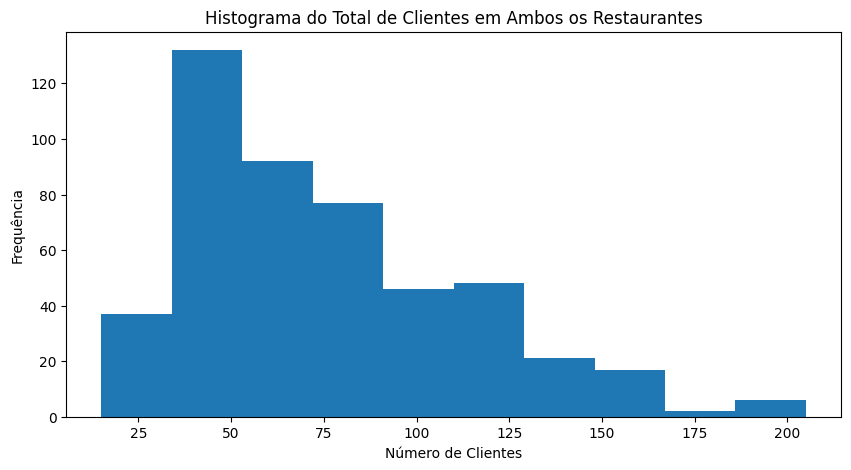

In [80]:
plt.figure(figsize=(10,5))
plt.hist(dados['Total'])
plt.title('Histograma do Total de Clientes em Ambos os Restaurantes')
plt.xlabel('Número de Clientes')
plt.ylabel('Frequência')
plt.show()

In [81]:
dados.describe()    

,Chimi & Churri,Assa Frão,Total
count,478.000000,478.000000,478.000000
mean,37.453975,37.679916,75.133891
std,21.433065,24.619708,37.514146
min,1.000000,3.000000,15.000000
25%,22.250000,19.000000,45.000000
50%,33.000000,30.500000,66.500000
75%,49.000000,50.000000,99.000000
max,128.000000,139.000000,205.000000


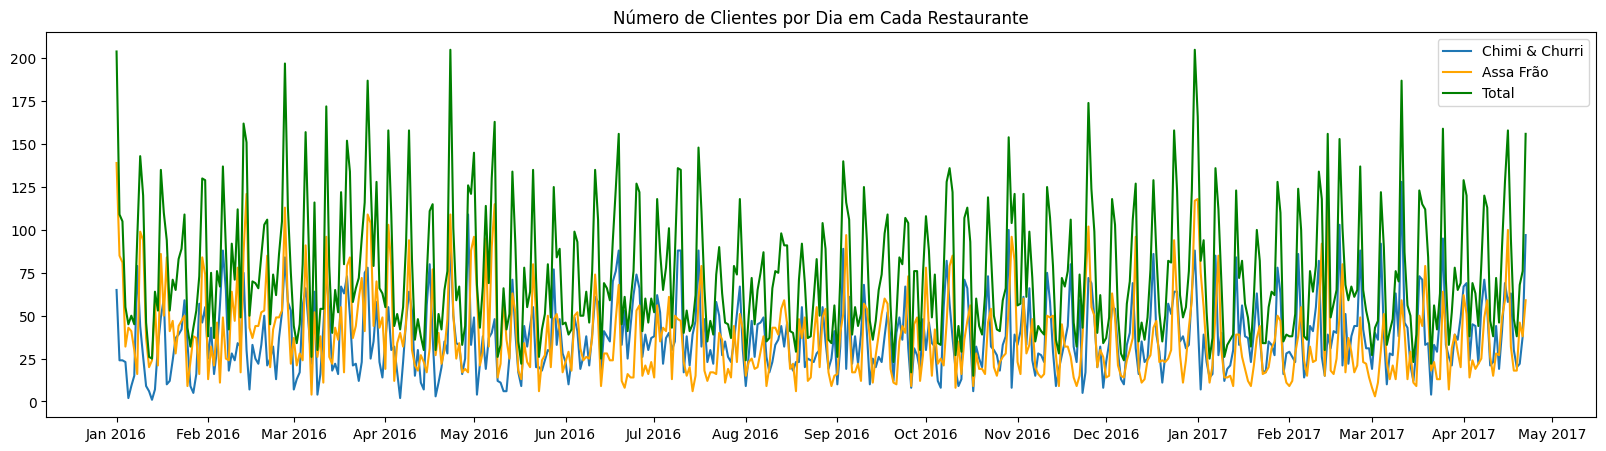

In [94]:
plt.figure(figsize=(20,5))
plt.plot(dados['Chimi & Churri'], label='Chimi & Churri')
plt.plot(dados['Assa Frão'], label='Assa Frão', color='orange')
plt.plot(dados['Total'], label='Total', color='green')
plt.title('Número de Clientes por Dia em Cada Restaurante')

# Obter o Axes atual e atribuir a 'ax'
ax = plt.gca() 

ax.xaxis.set_major_locator(dates.MonthLocator())
ax.xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))

plt.legend()
plt.show()

In [88]:
from matplotlib import dates

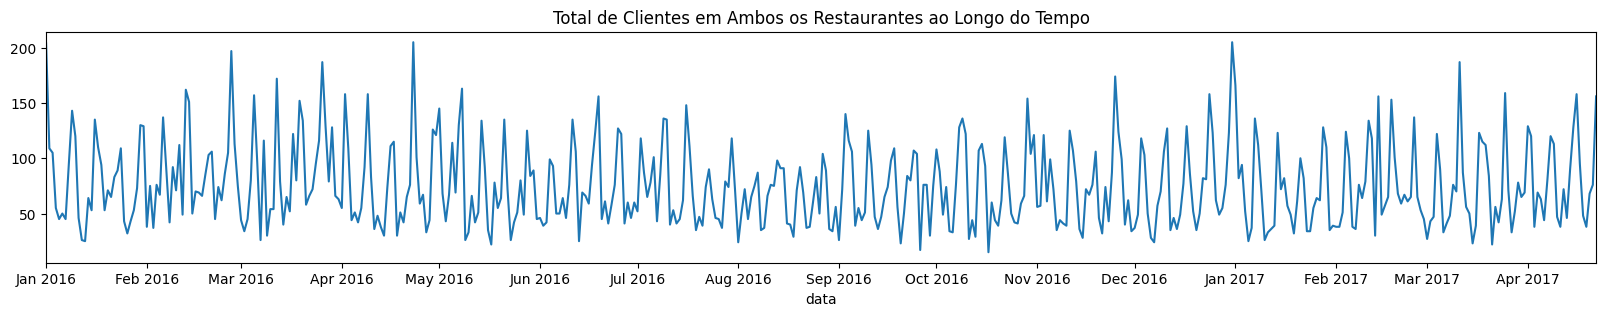

In [89]:
ax = dados['Total'].plot(figsize=(20,3), title='Total de Clientes em Ambos os Restaurantes ao Longo do Tempo')
ax.xaxis.set_major_locator(dates.MonthLocator())
ax.xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
plt.show()